First 5 Rows
   PassengerId               Name   Sex   Age  Pclass    Fare Embarked Cabin  \
0            1  Jennifer Petersen  male  36.0   First   43.49        Q   o66   
1            2  Christopher Ellis  male   NaN   Third   32.49        Q   B62   
2            3   Donald Robertson  male  70.0   Third  117.81        S   O51   
3            4       James Larson  male  55.0   Third   47.32        S   NaN   
4            5        Mark Harmon  male  45.0  Second  203.71        Q   NaN   

   Survived  
0         0  
1         0  
2         1  
3         1  
4         1  

Dataset Shape:
(300, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  300 non-null    int64  
 1   Name         300 non-null    object 
 2   Sex          300 non-null    object 
 3   Age          271 non-null    float64
 4   Pclass       300 non-

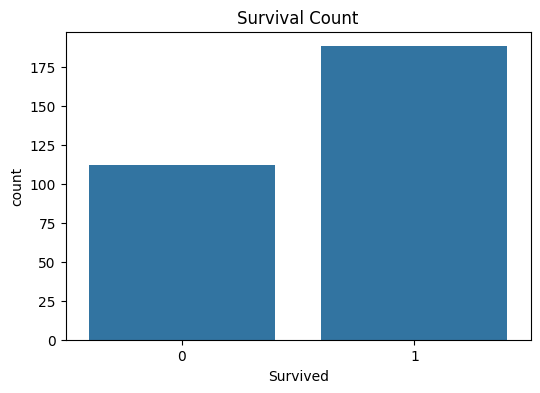

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Load Dataset
# -------------------------------

df = pd.read_csv("/content/titanic_eda_dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# -------------------------------
# 2. Dataset Information
# -------------------------------

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# -------------------------------
# 3. Missing Values
# -------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Cabin values
df['Cabin'] = df['Cabin'].fillna('Unknown')

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# -------------------------------
# 4. Duplicate Records
# -------------------------------

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df.shape)

# -------------------------------
# 5. Survival Distribution
# -------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()


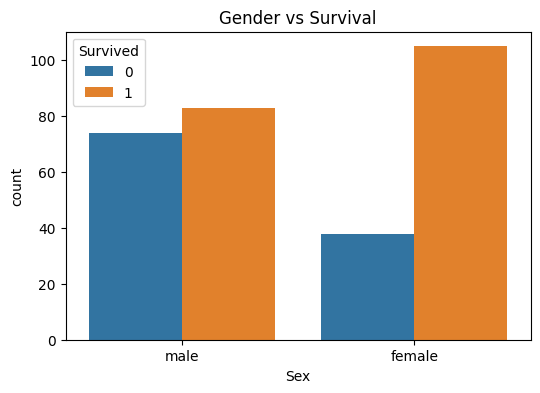

In [2]:
# -------------------------------
# 6. Gender vs Survival
# -------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

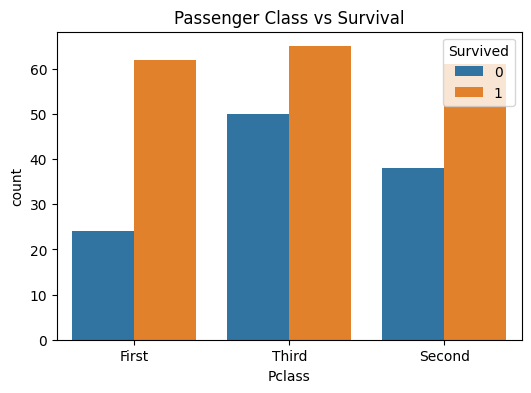

In [3]:
# -------------------------------
# 7. Passenger Class vs Survival
# -------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()


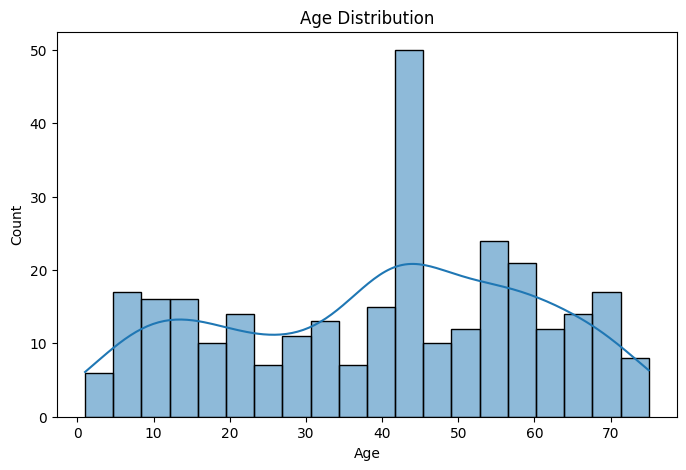

In [4]:
# -------------------------------
# 8. Age Distribution
# -------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

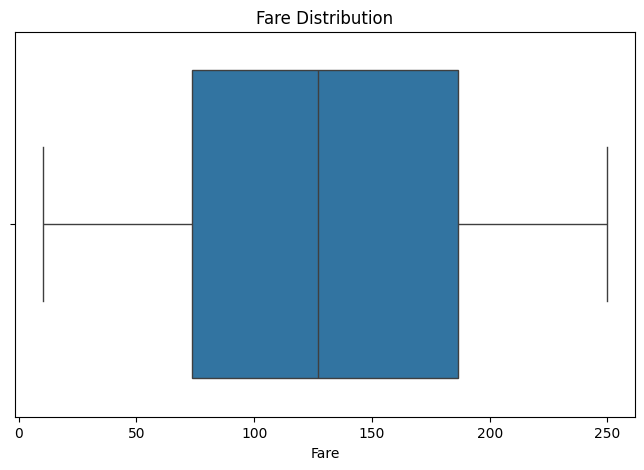

In [5]:
# -------------------------------
# 9. Fare Distribution
# -------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare Distribution")
plt.show()



Survival Percentage by Passenger Class
Survived          0          1
Pclass                        
First     27.906977  72.093023
Second    38.383838  61.616162
Third     43.478261  56.521739


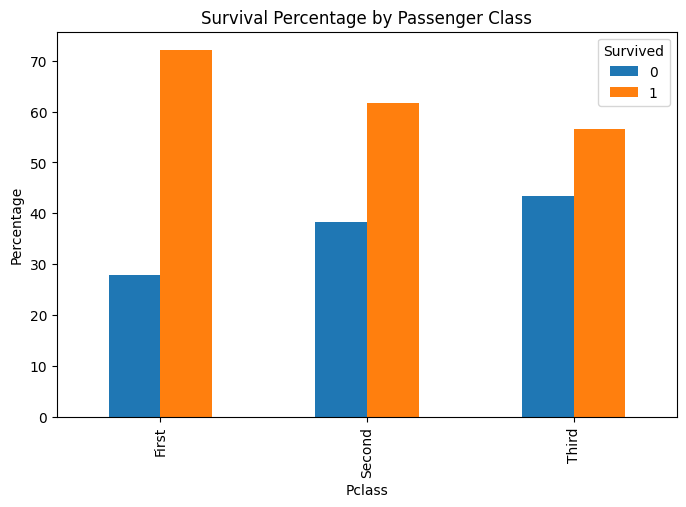

In [6]:
# -------------------------------
# 10. Survival Percentage by Class
# -------------------------------

survival_rate = pd.crosstab(
    df['Pclass'],
    df['Survived'],
    normalize='index'
) * 100

print("\nSurvival Percentage by Passenger Class")
print(survival_rate)

survival_rate.plot(kind='bar', figsize=(8,5))
plt.title("Survival Percentage by Passenger Class")
plt.ylabel("Percentage")
plt.show()


Survival Percentage by Gender
Survived          0          1
Sex                           
female    26.573427  73.426573
male      47.133758  52.866242


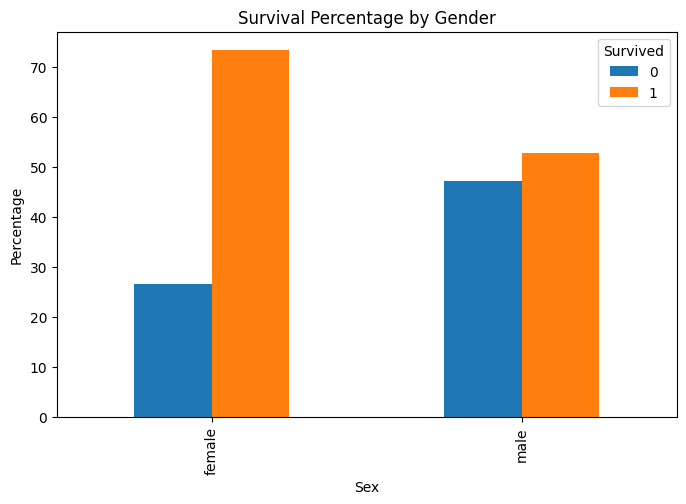

In [7]:
# -------------------------------
# 11. Survival Percentage by Gender
# -------------------------------

gender_survival = pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize='index'
) * 100

print("\nSurvival Percentage by Gender")
print(gender_survival)

gender_survival.plot(kind='bar', figsize=(8,5))
plt.title("Survival Percentage by Gender")
plt.ylabel("Percentage")
plt.show()


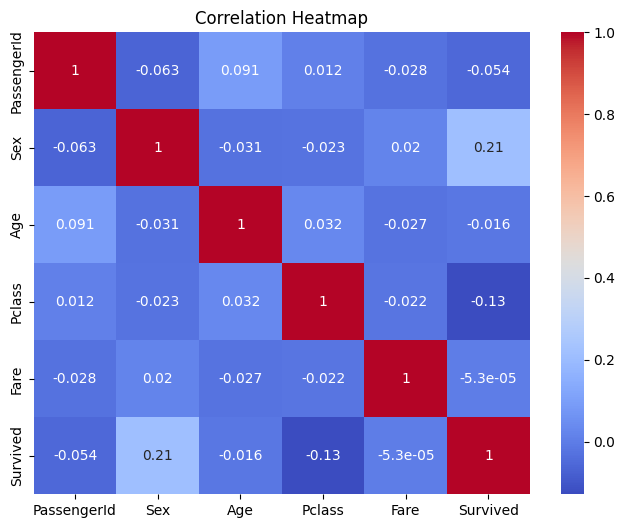

In [8]:
# -------------------------------
# 12. Correlation Heatmap
# -------------------------------

df_encoded = df.copy()

df_encoded['Sex'] = df_encoded['Sex'].map({
    'male':0,
    'female':1
})

df_encoded['Pclass'] = df_encoded['Pclass'].map({
    'First':1,
    'Second':2,
    'Third':3
})

plt.figure(figsize=(8,6))
sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


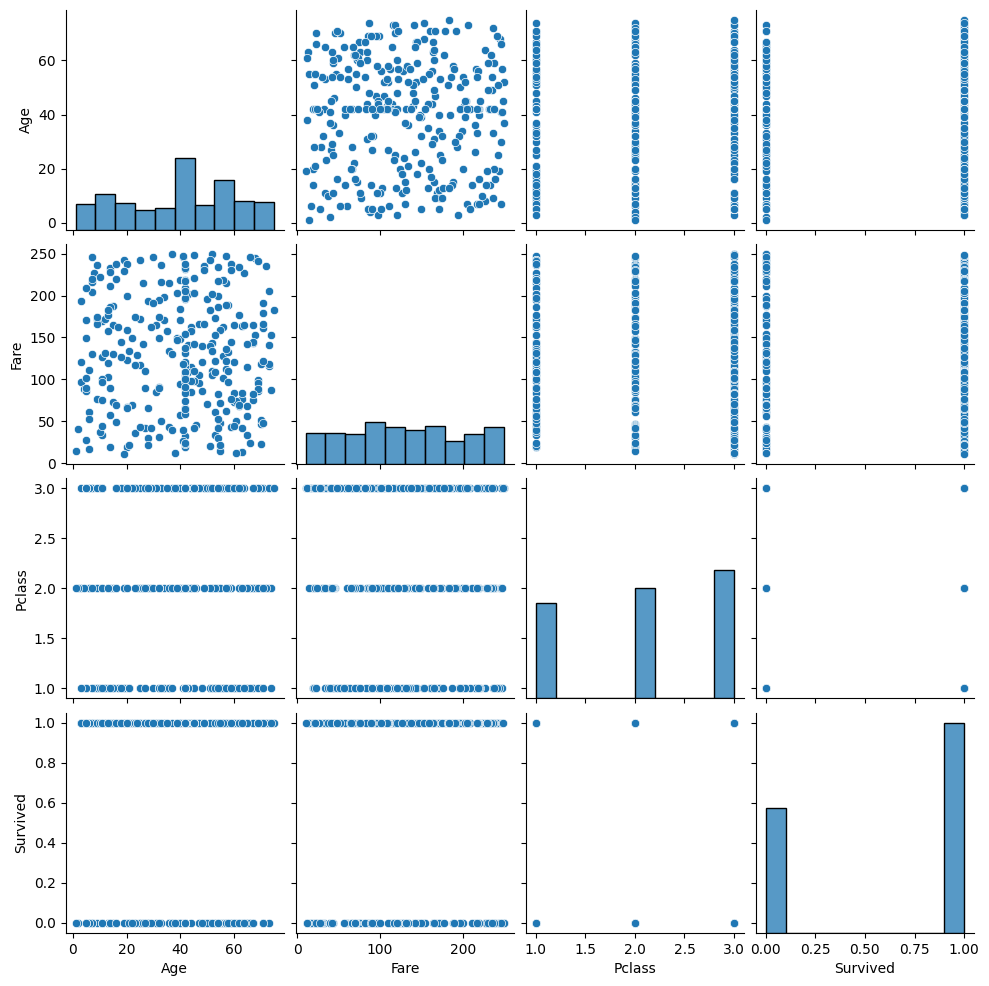

In [9]:
# -------------------------------
# 13. Pair Plot
# -------------------------------

sns.pairplot(
    df_encoded[['Age','Fare','Pclass','Survived']]
)

plt.show()
